# 03 — Exploratory Data Analysis

This notebook provides:
1. Summary statistics for the analysis panel
2. Medicaid expansion timeline visualization
3. Pre-trends analysis (critical for DiD validity)
4. Outcome distributions by expansion status
5. Correlation analysis of covariates

**Input:** `data/processed/analysis_panel.csv`  
**Output:** Publication-quality figures saved to `figures/`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os

# Plot settings
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 150,
    'font.size': 11,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

COLORS = {
    'expansion': '#2171b5',
    'no_expansion': '#cb181d',
    'highlight': '#238b45',
    'neutral': '#969696'
}

os.makedirs('../figures', exist_ok=True)

# Load panel
panel = pd.read_csv('../data/processed/analysis_panel.csv')
print(f"Panel loaded: {panel.shape}")
print(f"States: {panel['state'].nunique()}, Years: {panel['year'].min()}–{panel['year'].max()}")

Panel loaded: (663, 32)
States: 51, Years: 2010–2022


---
## 1. Summary Statistics

In [2]:
# Identify available numeric columns (excluding identifiers & treatment vars)
exclude_cols = ['state_fips', 'year', 'expansion_year', 'ever_expanded',
                'post_expansion', 'event_time', 'cohort_group', 'treat_x_post']
numeric_cols = [c for c in panel.select_dtypes(include=[np.number]).columns
                if c not in exclude_cols]

print(f"Available numeric variables: {len(numeric_cols)}")
print(numeric_cols)

if numeric_cols:
    summary = panel[numeric_cols].describe().T
    summary['missing_pct'] = (panel[numeric_cols].isnull().mean() * 100).round(1)
    display(summary.round(2))

Available numeric variables: 22
['allcause_deaths', 'allcause_population', 'allcause_crude_rate', 'allcause_age_adj_rate', 'diabetes_deaths', 'diabetes_population', 'diabetes_crude_rate', 'diabetes_age_adj_rate', 'maternal_deaths', 'maternal_population', 'maternal_crude_rate', 'maternal_age_adj_rate', 'total_population', 'median_household_income', 'poverty_rate', 'pct_white', 'pct_black', 'pct_hispanic', 'diabetes_prevalence', 'total_births', 'birth_rate', 'avg_birth_weight_g']


,count,mean,std,min,25%,50%,75%,max,missing_pct
allcause_deaths,663.0,55569.87,56426.51,3728.00,15371.00,40890.00,68634.00,333249.00,0.0
allcause_population,663.0,6319118.07,7133072.90,563626.00,1779057.50,4436974.00,7277516.50,39557045.00,0.0
allcause_crude_rate,663.0,912.76,161.87,524.90,803.90,904.80,1005.65,1654.70,0.0
allcause_age_adj_rate,663.0,777.99,106.47,572.00,709.55,751.60,837.40,1229.10,0.0
diabetes_deaths,663.0,1646.06,1777.77,86.00,447.00,1201.00,2009.50,11642.00,0.0
diabetes_population,663.0,6319118.07,7133072.90,563626.00,1779057.50,4436974.00,7277516.50,39557045.00,0.0
diabetes_crude_rate,663.0,26.82,6.76,12.10,22.30,26.40,30.00,67.50,0.0
diabetes_age_adj_rate,663.0,22.54,4.80,11.40,19.25,22.10,25.00,47.60,0.0
maternal_deaths,386.0,35.50,29.12,10.00,16.00,27.00,43.00,206.00,41.8
maternal_population,386.0,4795129.88,3982115.54,782258.00,2392943.75,3389606.50,5437195.50,19893468.00,41.8


In [3]:
# Compare expansion vs non-expansion states (pre-period: 2010-2013)
pre = panel[panel['year'].between(2010, 2013)].copy()

if numeric_cols:
    comparison = pre.groupby('ever_expanded')[numeric_cols].agg(['mean', 'std']).round(2)
    
    # Flatten multi-level columns for display
    comparison.columns = ['_'.join(col) for col in comparison.columns]
    comparison = comparison.T
    comparison.columns = ['Non-Expansion', 'Expansion']
    
    print("Pre-Period (2010–2013) Comparison:\n")
    display(comparison)
else:
    print("No outcome data available yet. Download CDC data and re-run.")

Pre-Period (2010–2013) Comparison:



,Non-Expansion,Expansion
allcause_deaths_mean,68223.15,45092.92
allcause_deaths_std,56801.10,46871.14
allcause_population_mean,8294995.68,5601100.65
allcause_population_std,7721359.69,6582577.91
allcause_crude_rate_mean,870.14,832.27
allcause_crude_rate_std,110.40,125.95
allcause_age_adj_rate_mean,809.76,743.90
allcause_age_adj_rate_std,89.22,79.51
diabetes_deaths_mean,1953.08,1306.64
diabetes_deaths_std,1673.20,1420.99


---
## 2. Medicaid Expansion Timeline

Visualize when each state adopted Medicaid expansion — this is a key figure for the README.

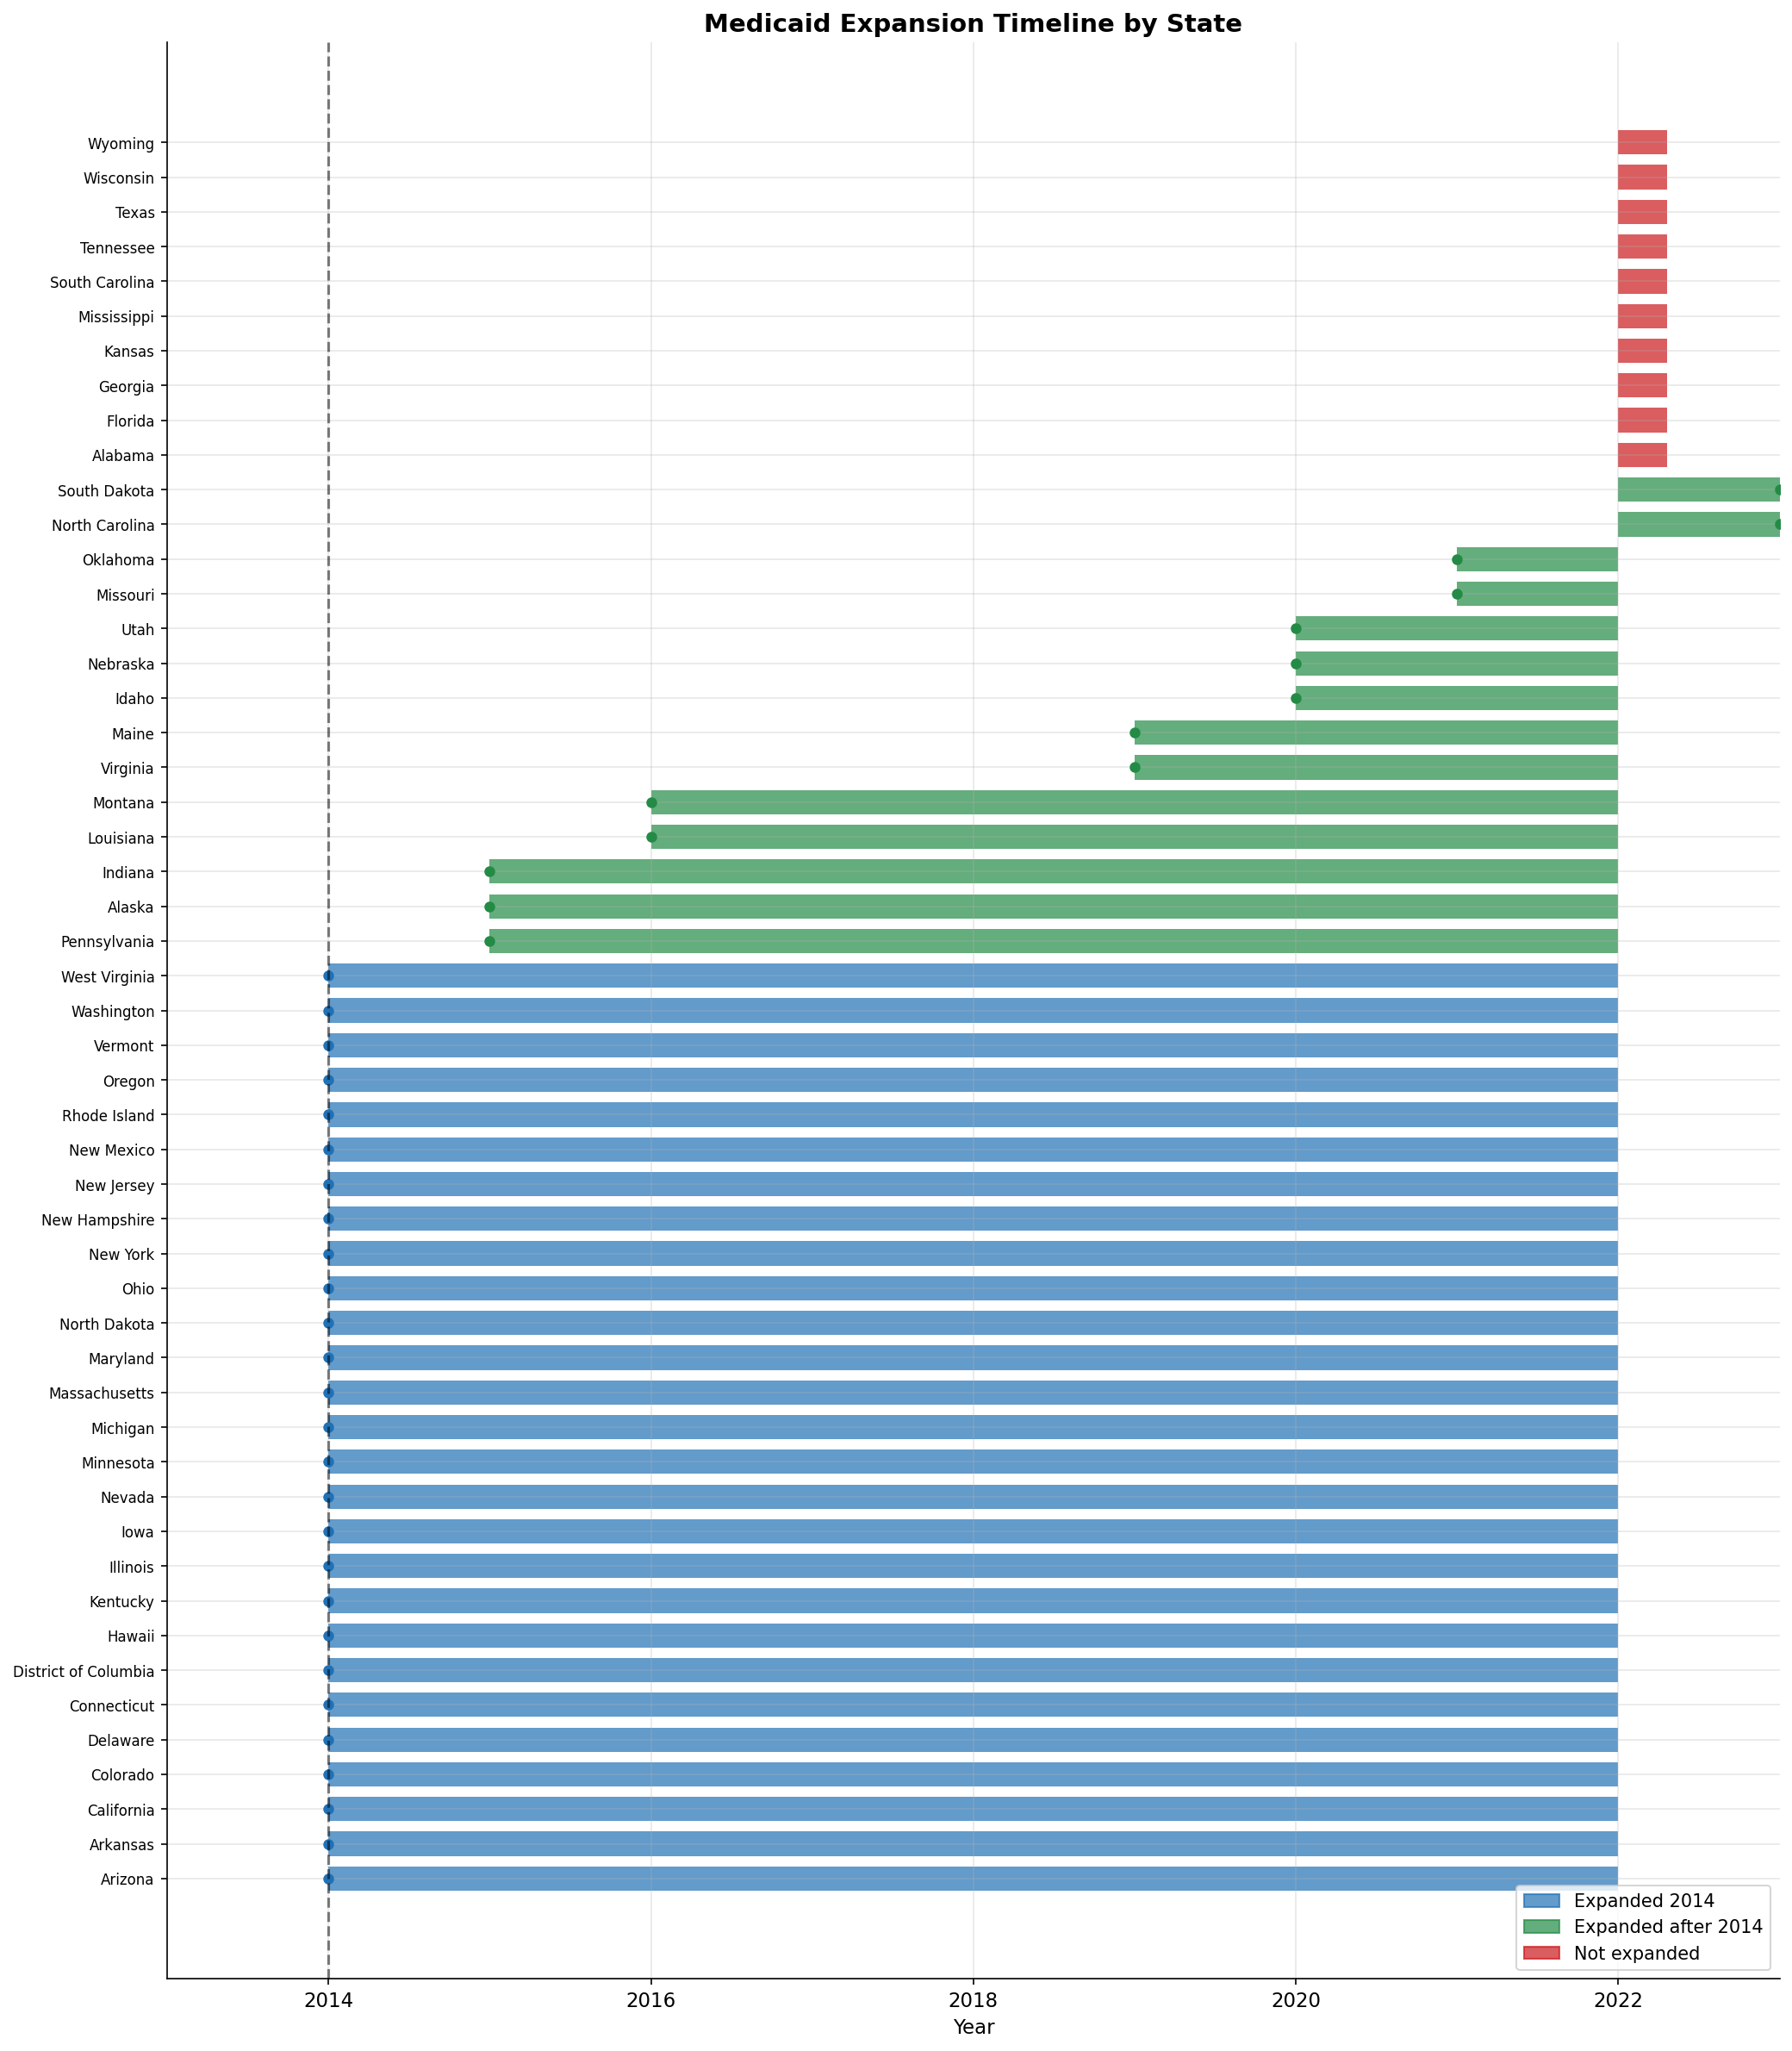

Saved: figures/expansion_timeline.png


In [4]:
# Get one row per state with expansion info
state_info = panel.groupby('state').agg(
    expansion_year=('expansion_year', 'first'),
    ever_expanded=('ever_expanded', 'first')
).reset_index()

# Sort: expanded states by year, then non-expanded alphabetically
expanded = state_info[state_info['ever_expanded'] == 1].sort_values('expansion_year')
not_expanded = state_info[state_info['ever_expanded'] == 0].sort_values('state')
state_order = pd.concat([expanded, not_expanded])

fig, ax = plt.subplots(figsize=(14, 16))

y_positions = range(len(state_order))

for i, (_, row) in enumerate(state_order.iterrows()):
    if row['ever_expanded'] == 1:
        color = COLORS['expansion'] if row['expansion_year'] == 2014 else COLORS['highlight']
        ax.barh(i, 2022 - row['expansion_year'], left=row['expansion_year'],
                color=color, alpha=0.7, height=0.7)
        ax.plot(row['expansion_year'], i, 'o', color=color, markersize=5)
    else:
        ax.barh(i, 0.3, left=2022, color=COLORS['no_expansion'], alpha=0.7, height=0.7)

ax.set_yticks(y_positions)
ax.set_yticklabels(state_order['state'], fontsize=8)
ax.set_xlabel('Year')
ax.set_xlim(2013, 2023)
ax.set_title('Medicaid Expansion Timeline by State', fontsize=14, fontweight='bold')
ax.axvline(x=2014, color='black', linestyle='--', alpha=0.5, label='ACA Expansion Start')

# Legend
legend_elements = [
    mpatches.Patch(color=COLORS['expansion'], alpha=0.7, label='Expanded 2014'),
    mpatches.Patch(color=COLORS['highlight'], alpha=0.7, label='Expanded after 2014'),
    mpatches.Patch(color=COLORS['no_expansion'], alpha=0.7, label='Not expanded'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('../figures/expansion_timeline.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/expansion_timeline.png")

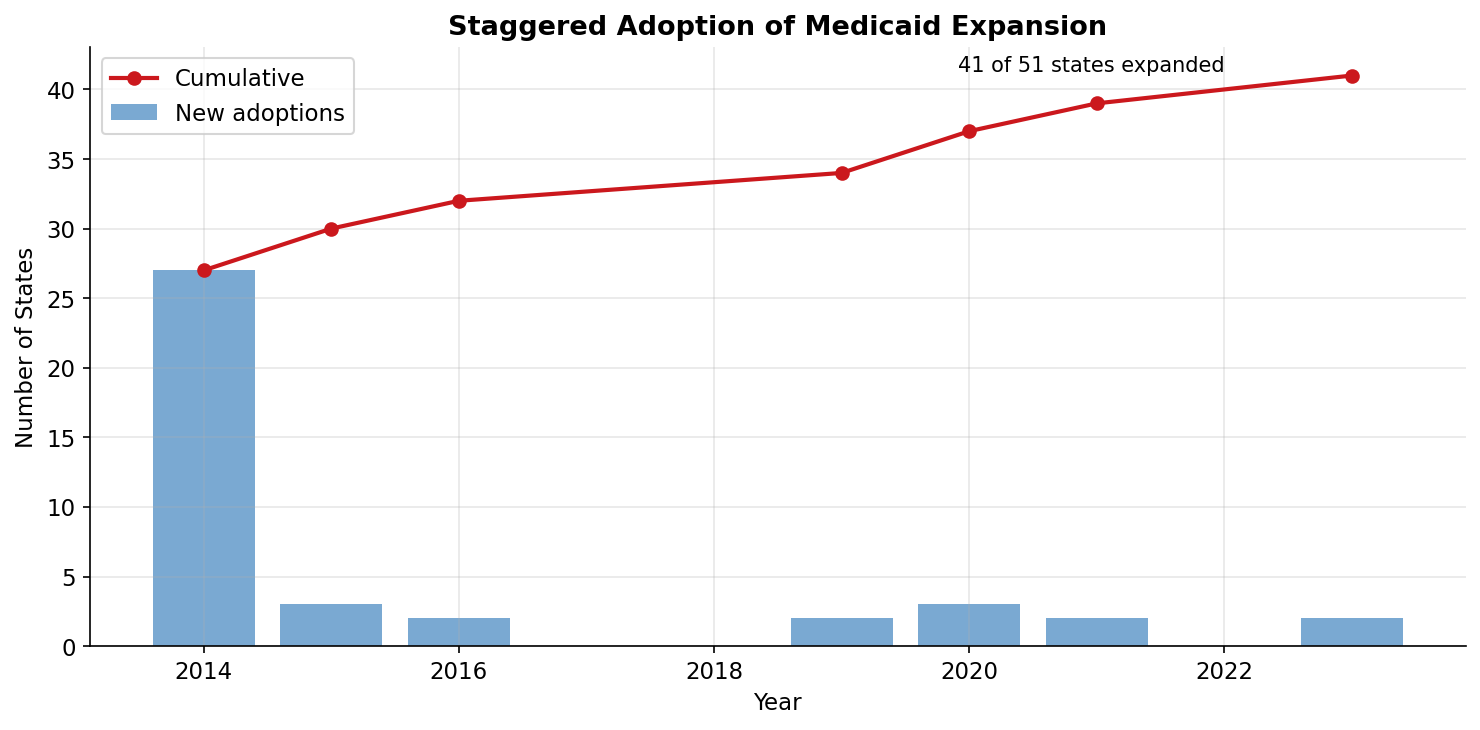

Saved: figures/expansion_adoption_curve.png


In [5]:
# Expansion adoption over time (cumulative)
expansion_counts = state_info[state_info['ever_expanded'] == 1]['expansion_year'].value_counts().sort_index()
cumulative = expansion_counts.cumsum()

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(expansion_counts.index, expansion_counts.values, 
       color=COLORS['expansion'], alpha=0.6, label='New adoptions')
ax.plot(cumulative.index, cumulative.values, 'o-', 
        color=COLORS['no_expansion'], linewidth=2, label='Cumulative')

ax.set_xlabel('Year')
ax.set_ylabel('Number of States')
ax.set_title('Staggered Adoption of Medicaid Expansion', fontsize=13, fontweight='bold')
ax.legend()

# Annotate total
total_expanded = state_info['ever_expanded'].sum()
total_states = len(state_info)
ax.annotate(f'{total_expanded} of {total_states} states expanded',
            xy=(2022, cumulative.iloc[-1]), fontsize=10,
            ha='right', va='bottom')

plt.tight_layout()
plt.savefig('../figures/expansion_adoption_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: figures/expansion_adoption_curve.png")

---
## 3. Covariate Trends: Expansion vs Non-Expansion

Plot the available covariates over time, split by expansion status. This helps assess whether the groups are comparable.

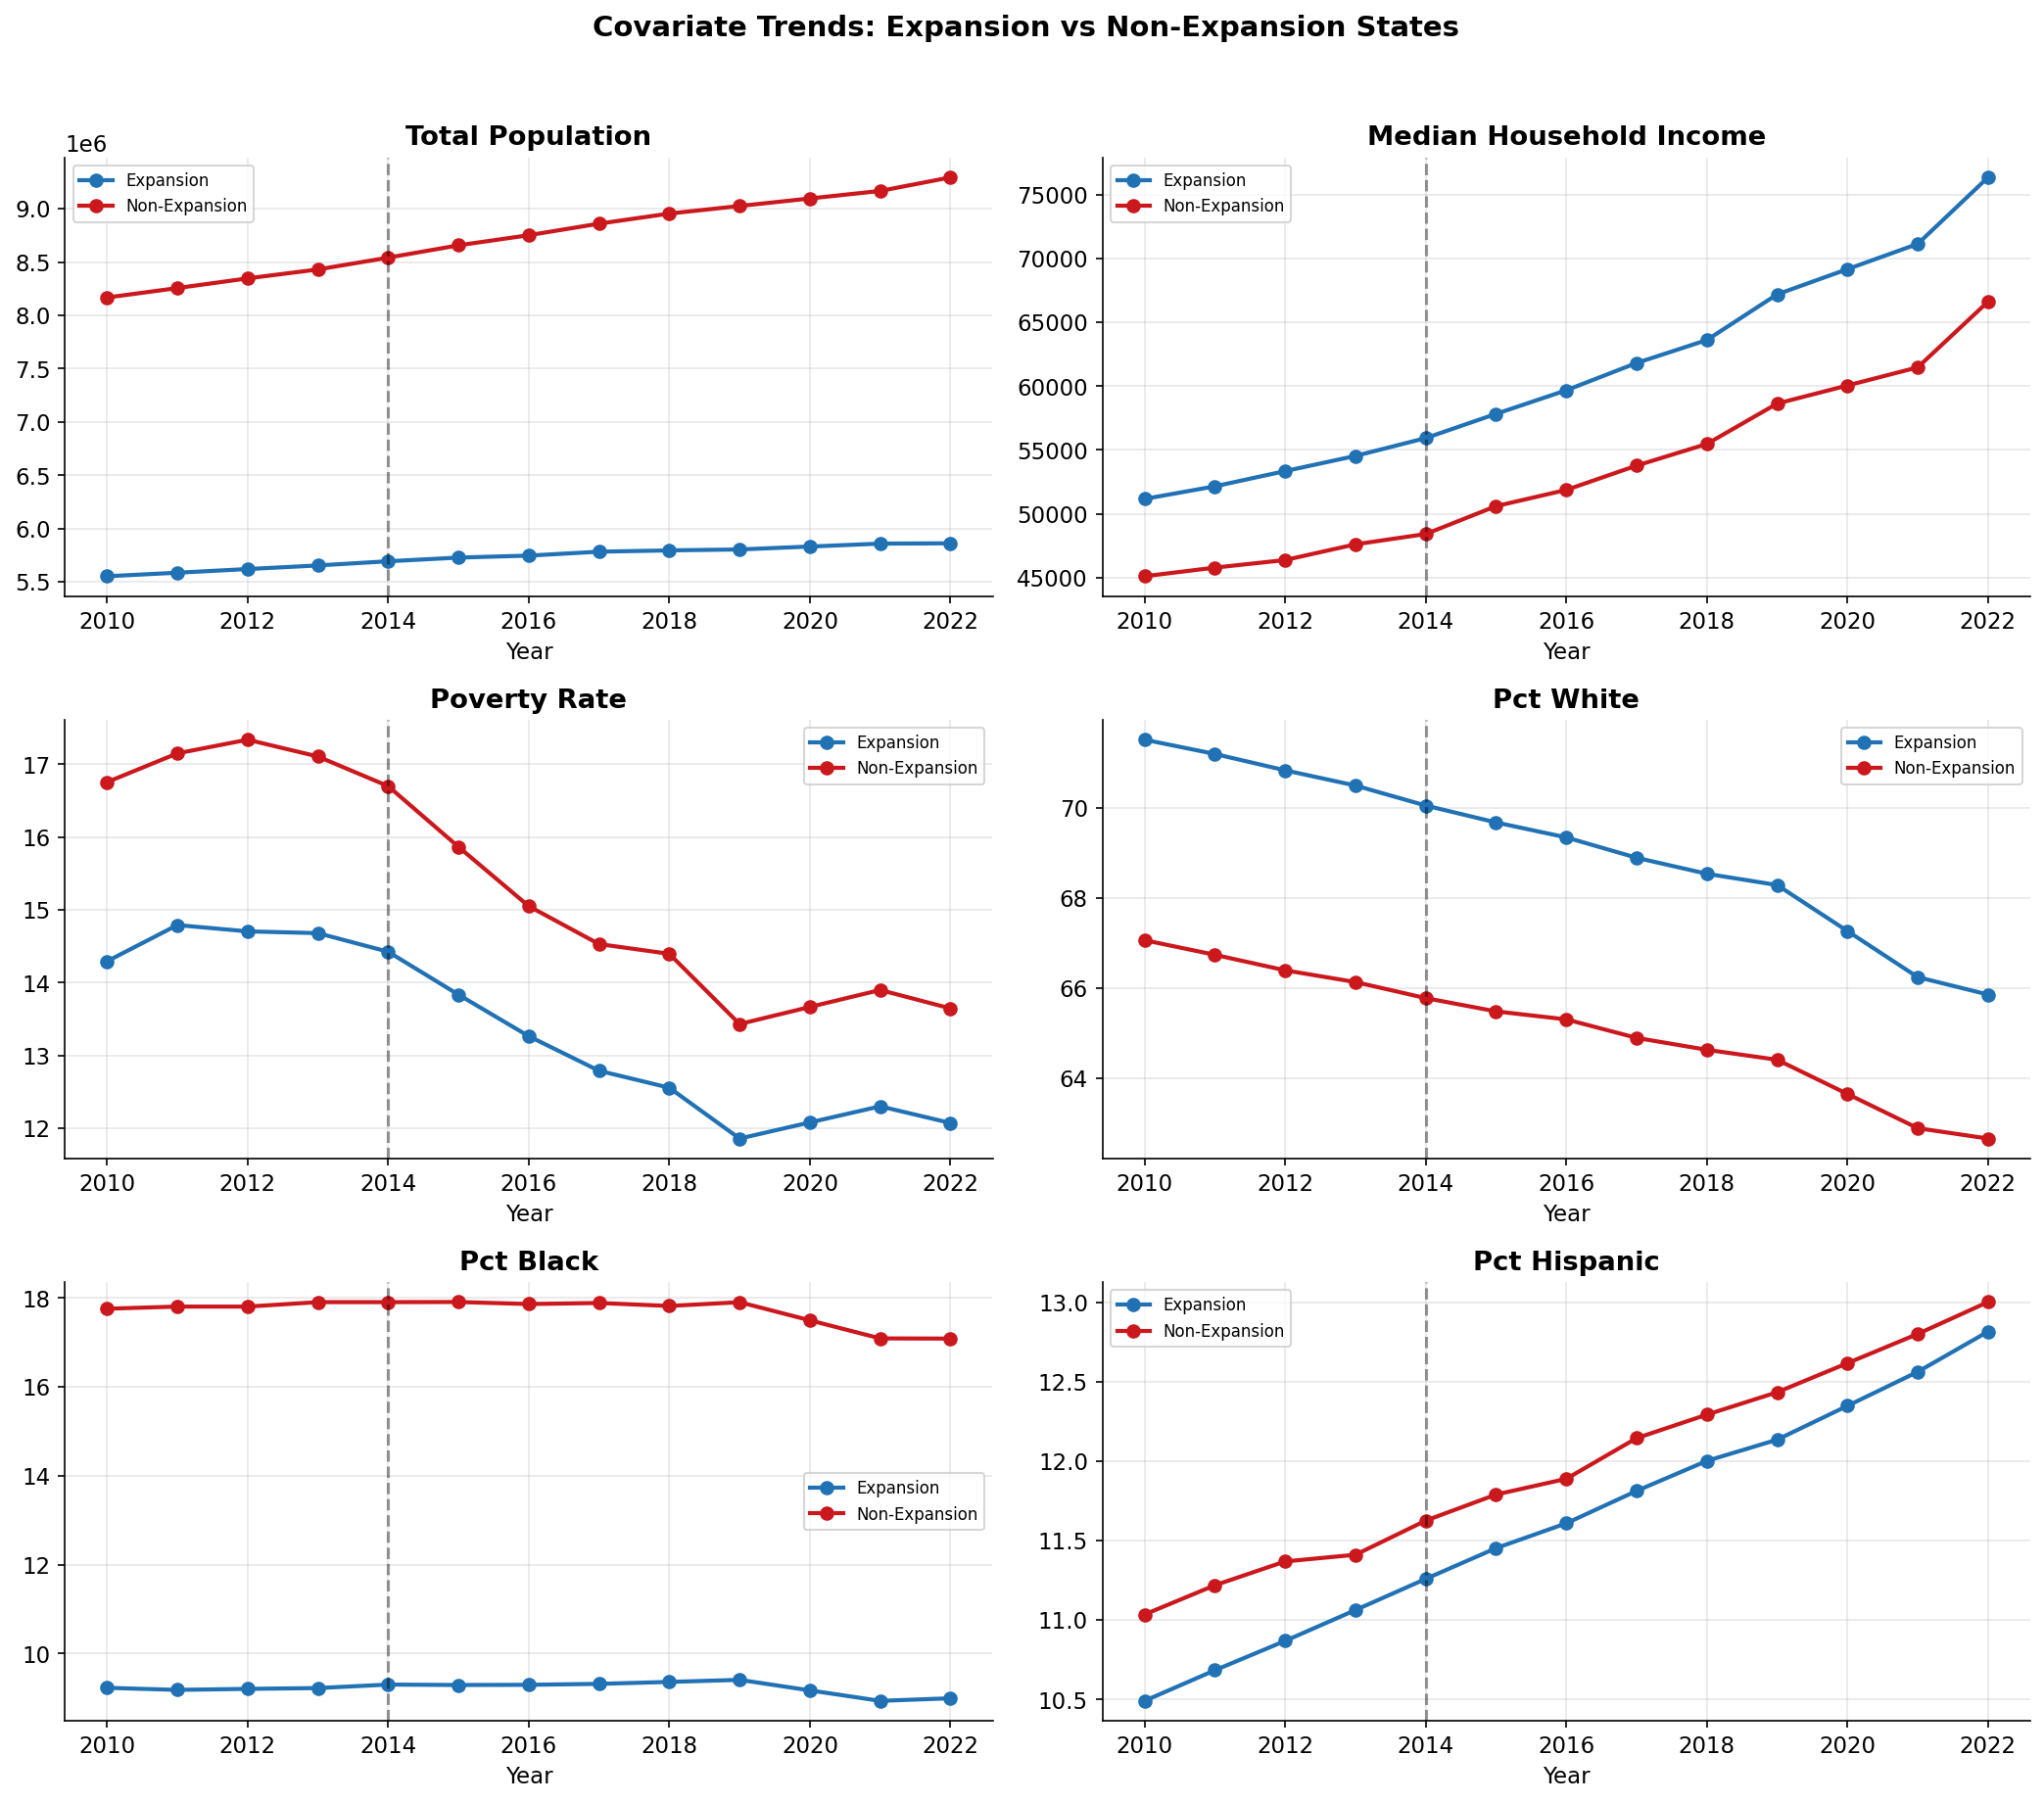

Saved: figures/covariate_trends.png


In [6]:
# Identify available ACS/control variables
acs_vars = [c for c in panel.columns if c in [
    'total_population', 'median_household_income', 'poverty_rate',
    'pct_white', 'pct_black', 'pct_hispanic',
    'uninsured_rate', 'unemployment_rate'
]]

if acs_vars:
    n_vars = len(acs_vars)
    n_cols = 2
    n_rows = (n_vars + 1) // 2
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
    axes = axes.flatten() if n_vars > 1 else [axes]
    
    for i, var in enumerate(acs_vars):
        ax = axes[i]
        
        # Group means by expansion status and year
        grouped = panel.groupby(['year', 'ever_expanded'])[var].mean().reset_index()
        
        for exp_status, color, label in [
            (1, COLORS['expansion'], 'Expansion'),
            (0, COLORS['no_expansion'], 'Non-Expansion')
        ]:
            data = grouped[grouped['ever_expanded'] == exp_status]
            ax.plot(data['year'], data[var], 'o-', color=color, label=label, linewidth=2)
        
        ax.axvline(x=2014, color='black', linestyle='--', alpha=0.4)
        ax.set_title(var.replace('_', ' ').title(), fontweight='bold')
        ax.set_xlabel('Year')
        ax.legend(fontsize=8)
    
    # Hide empty subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    plt.suptitle('Covariate Trends: Expansion vs Non-Expansion States',
                 fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('../figures/covariate_trends.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: figures/covariate_trends.png")
else:
    print("No ACS control variables available. Get a Census API key and run notebook 01.")

---
## 4. Pre-Trends Analysis (Key for DiD Validity)

The parallel trends assumption is the foundation of DiD. We plot outcome trends for expansion vs non-expansion states in the pre-period to visually assess whether trends were similar before treatment.

**What we want to see:** Lines moving roughly in parallel before 2014.

In [7]:
# Identify available outcome variables
outcome_candidates = [
    'allcause_age_adj_rate', 'allcause_crude_rate',
    'diabetes_age_adj_rate', 'diabetes_crude_rate',
    'maternal_age_adj_rate', 'maternal_crude_rate',
    'diabetes_prevalence', 'diabetes_incidence',
    'low_birth_weight_pct', 'total_births'
]
outcome_vars = [c for c in outcome_candidates if c in panel.columns and panel[c].notna().sum() > 50]

if outcome_vars:
    print(f"Available outcome variables for pre-trends: {outcome_vars}")
else:
    print("No outcome variables available yet.")
    print("Download CDC data, re-run notebooks 01 and 02, then come back here.")
    print("\nFor now, we'll demonstrate with ACS variables as a preview.")
    outcome_vars = [c for c in acs_vars if panel[c].notna().sum() > 50]

Available outcome variables for pre-trends: ['allcause_age_adj_rate', 'allcause_crude_rate', 'diabetes_age_adj_rate', 'diabetes_crude_rate', 'maternal_age_adj_rate', 'maternal_crude_rate', 'diabetes_prevalence', 'total_births']


In [8]:
def plot_pre_trends(panel, outcome_var, title=None):
    """
    Plot pre/post trends for expansion vs non-expansion states.
    Includes shaded confidence band and vertical treatment line.
    """
    if outcome_var not in panel.columns:
        print(f"Variable {outcome_var} not in panel.")
        return
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    for exp_status, color, label in [
        (1, COLORS['expansion'], 'Expansion States'),
        (0, COLORS['no_expansion'], 'Non-Expansion States')
    ]:
        subset = panel[panel['ever_expanded'] == exp_status]
        grouped = subset.groupby('year')[outcome_var].agg(['mean', 'std', 'count']).reset_index()
        grouped['se'] = grouped['std'] / np.sqrt(grouped['count'])
        grouped['ci_lower'] = grouped['mean'] - 1.96 * grouped['se']
        grouped['ci_upper'] = grouped['mean'] + 1.96 * grouped['se']
        
        ax.plot(grouped['year'], grouped['mean'], 'o-', color=color,
                linewidth=2.5, label=label, markersize=5)
        ax.fill_between(grouped['year'], grouped['ci_lower'], grouped['ci_upper'],
                        color=color, alpha=0.15)
    
    # Treatment line
    ax.axvline(x=2014, color='black', linestyle='--', alpha=0.6, linewidth=1.5)
    ax.text(2014.1, ax.get_ylim()[1] * 0.98, 'ACA Expansion\nBegins',
            fontsize=9, va='top', ha='left', style='italic')
    
    # Shade pre-period
    ax.axvspan(2010, 2014, alpha=0.05, color='gray')
    ax.text(2012, ax.get_ylim()[0], 'Pre-period', ha='center',
            fontsize=9, color='gray', alpha=0.7)
    
    if title is None:
        title = outcome_var.replace('_', ' ').title()
    ax.set_title(f'Pre-Trends Analysis: {title}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel(title)
    ax.legend(fontsize=10)
    
    plt.tight_layout()
    return fig

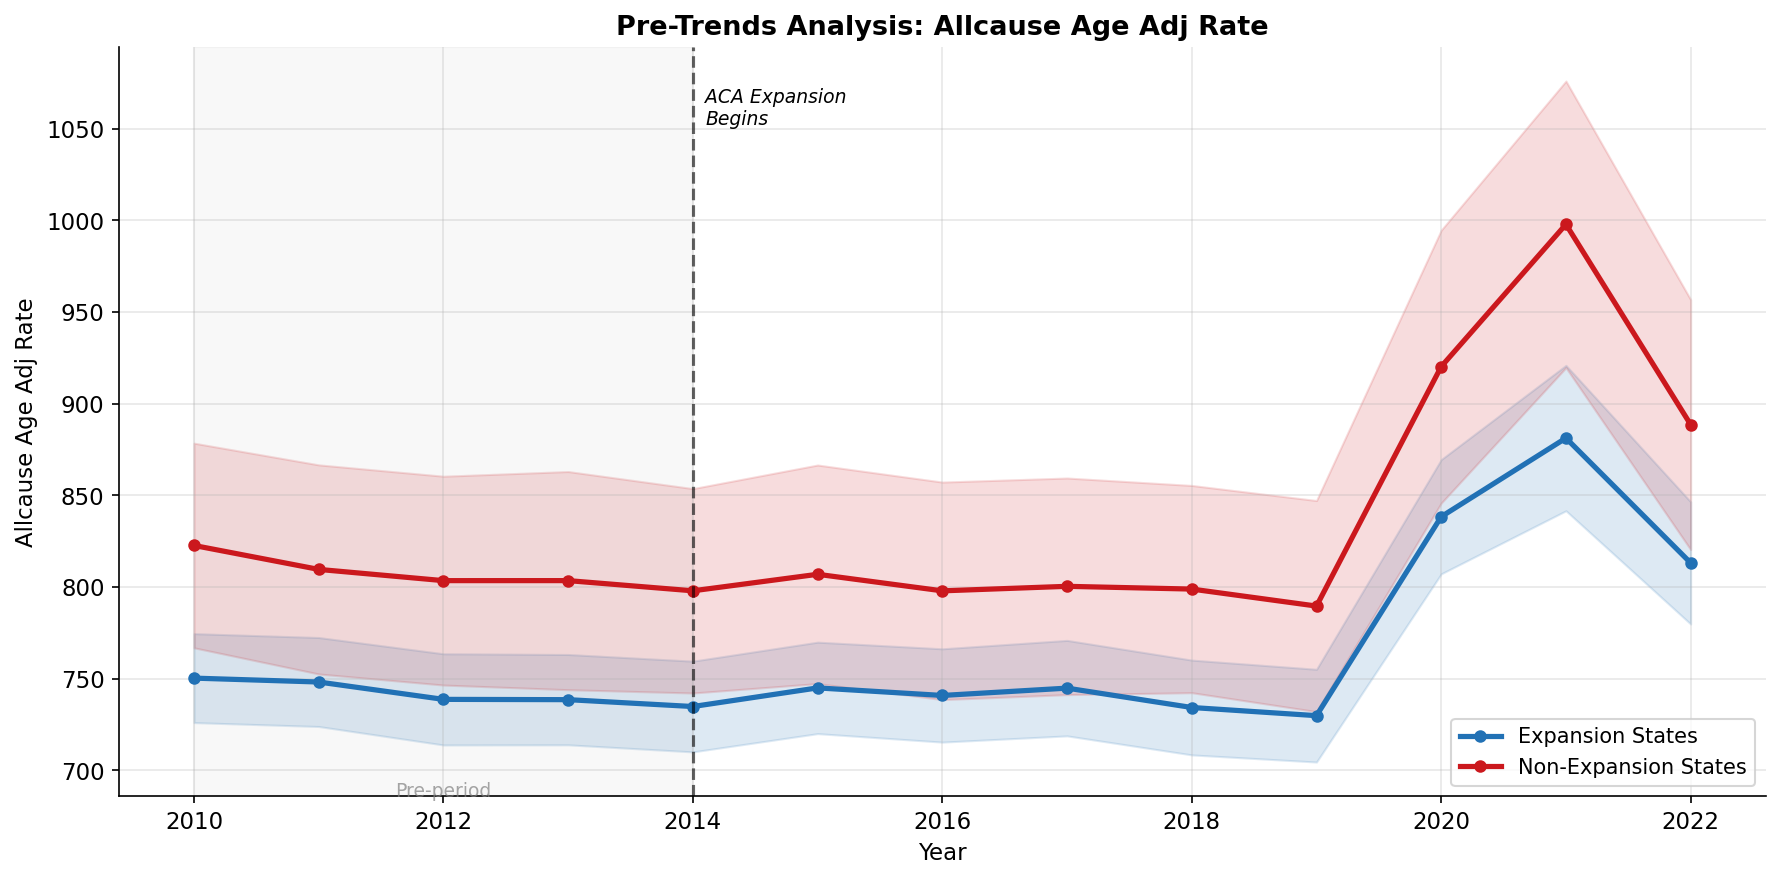

Saved: figures/pre_trends_allcause_age_adj_rate.png



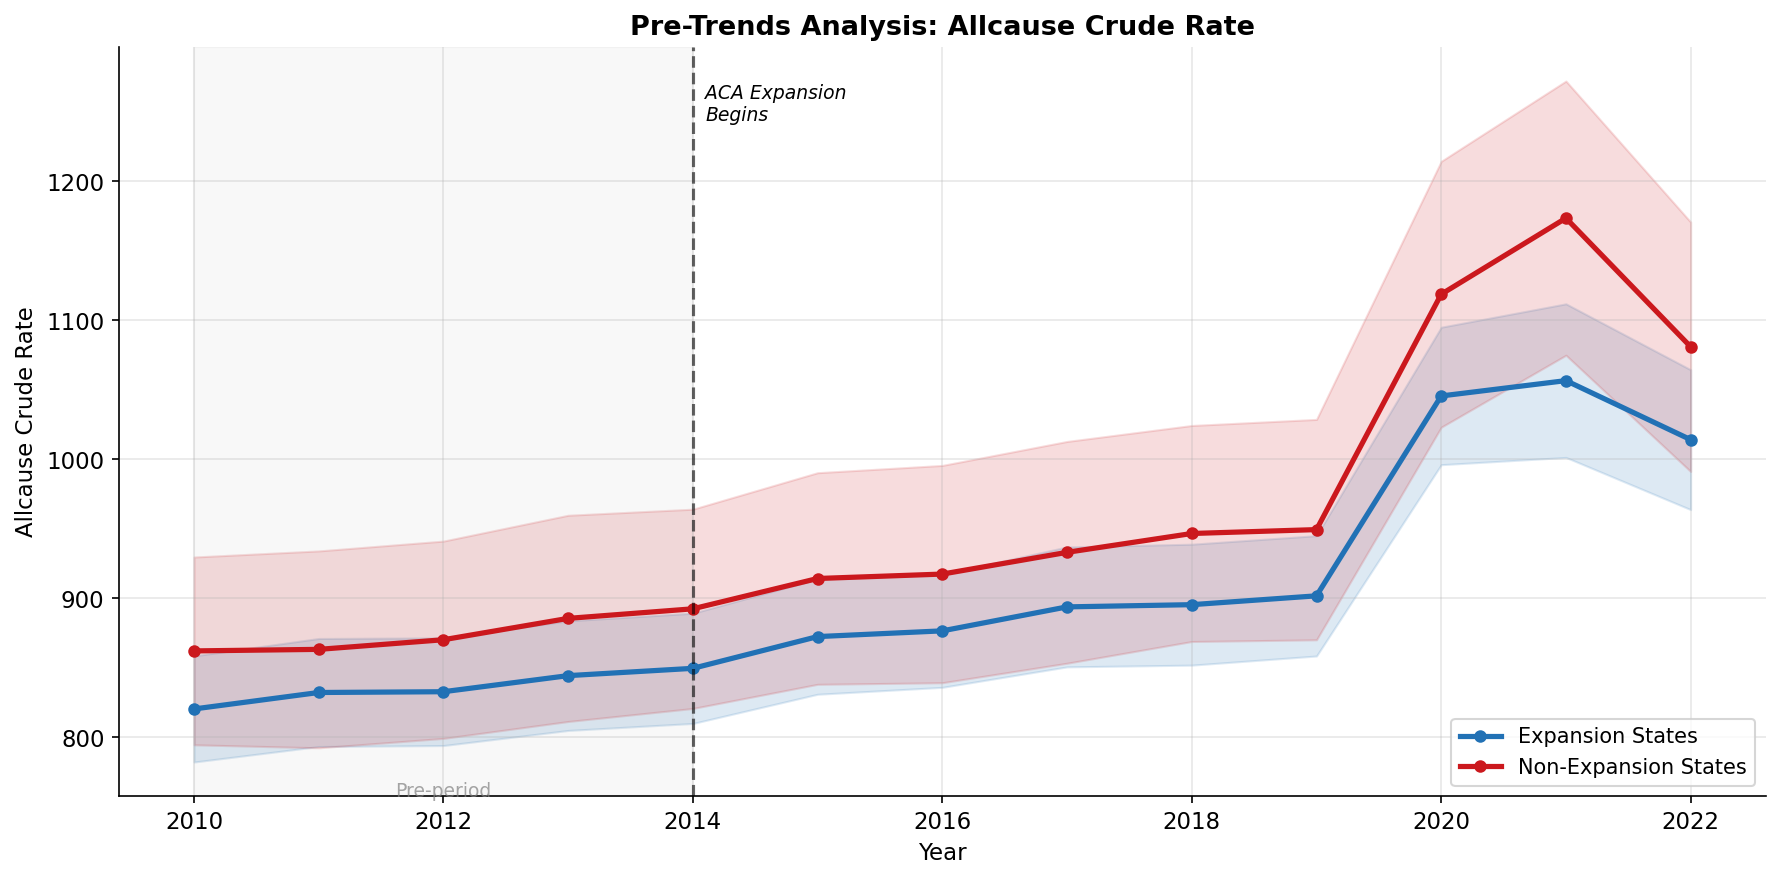

Saved: figures/pre_trends_allcause_crude_rate.png



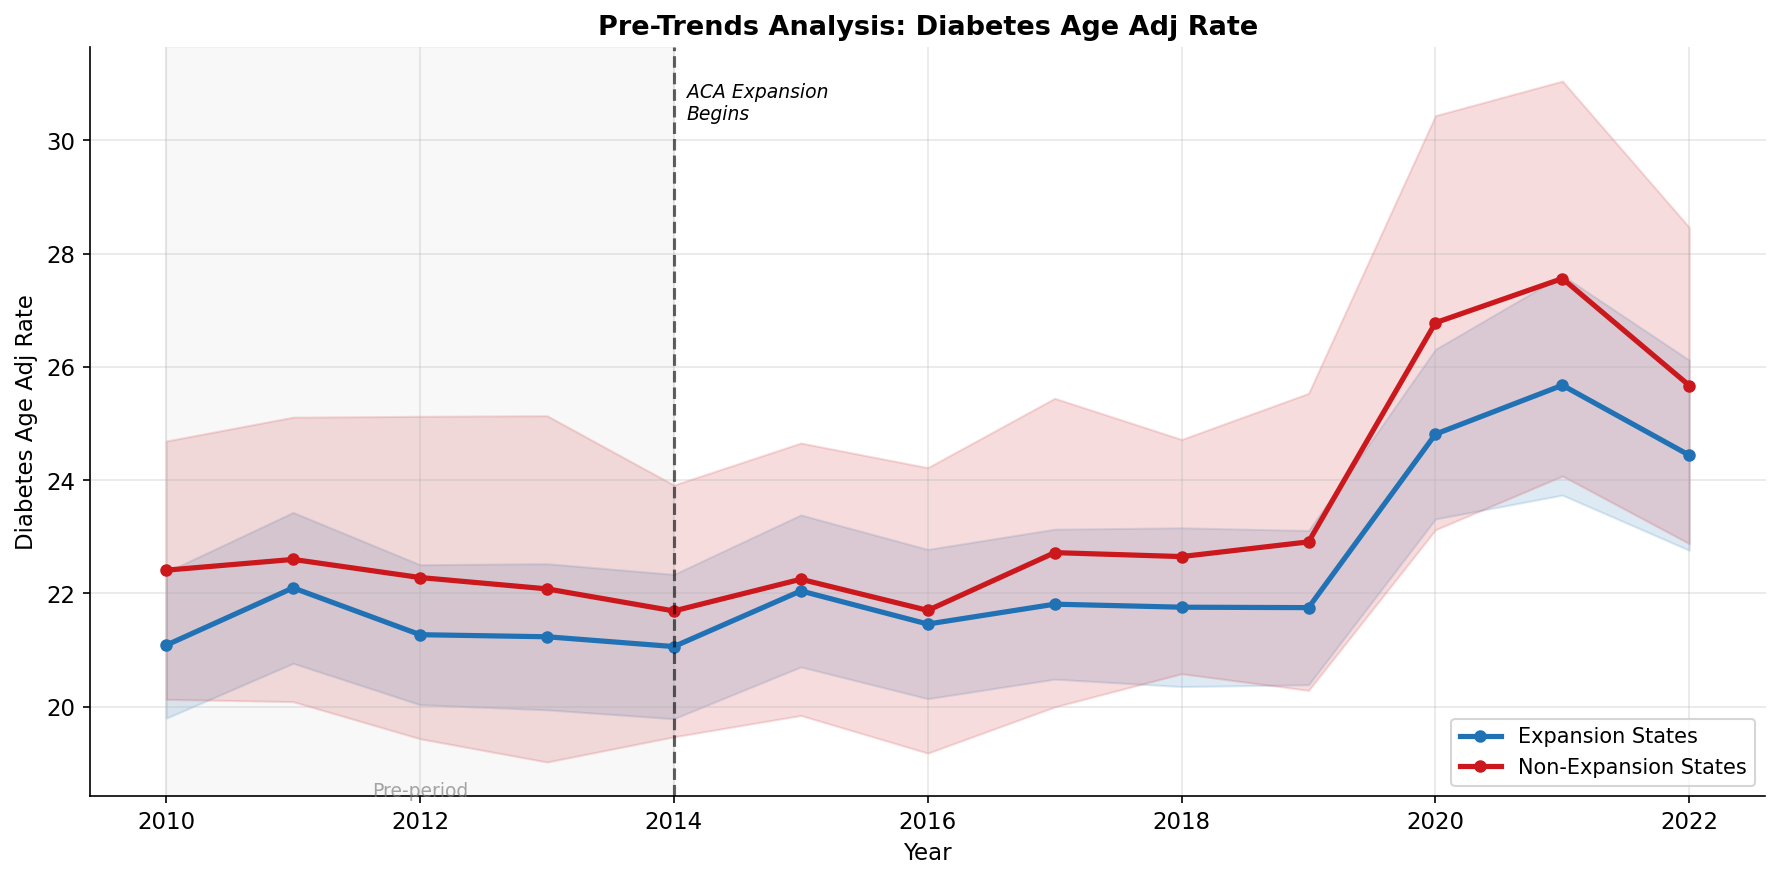

Saved: figures/pre_trends_diabetes_age_adj_rate.png



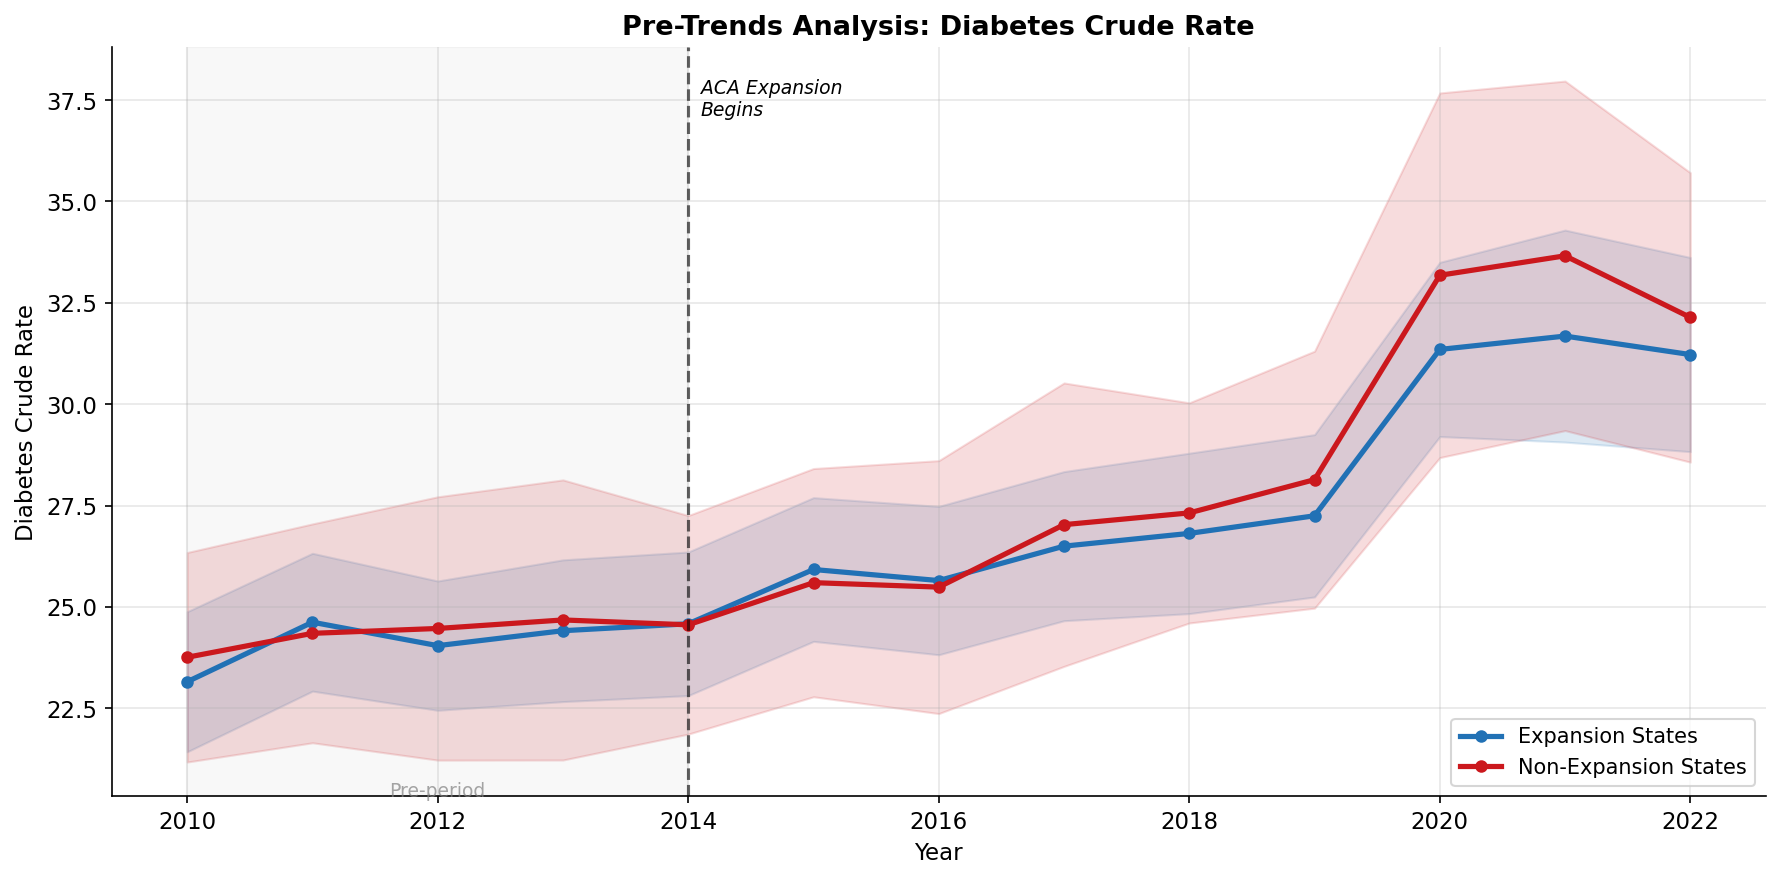

Saved: figures/pre_trends_diabetes_crude_rate.png



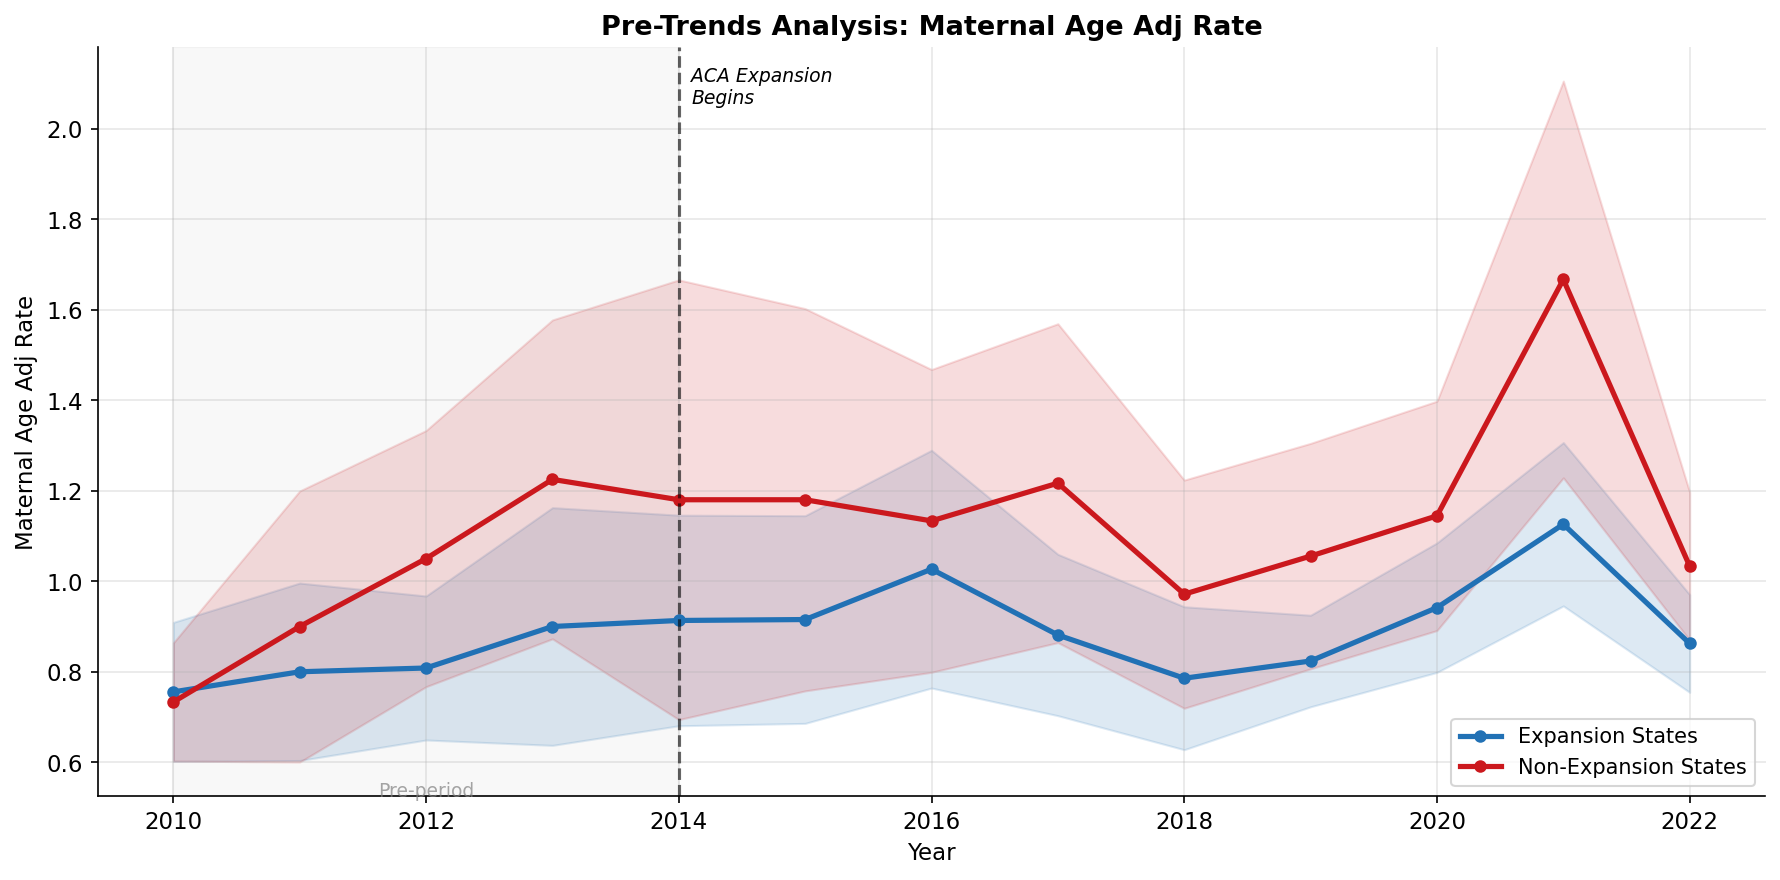

Saved: figures/pre_trends_maternal_age_adj_rate.png



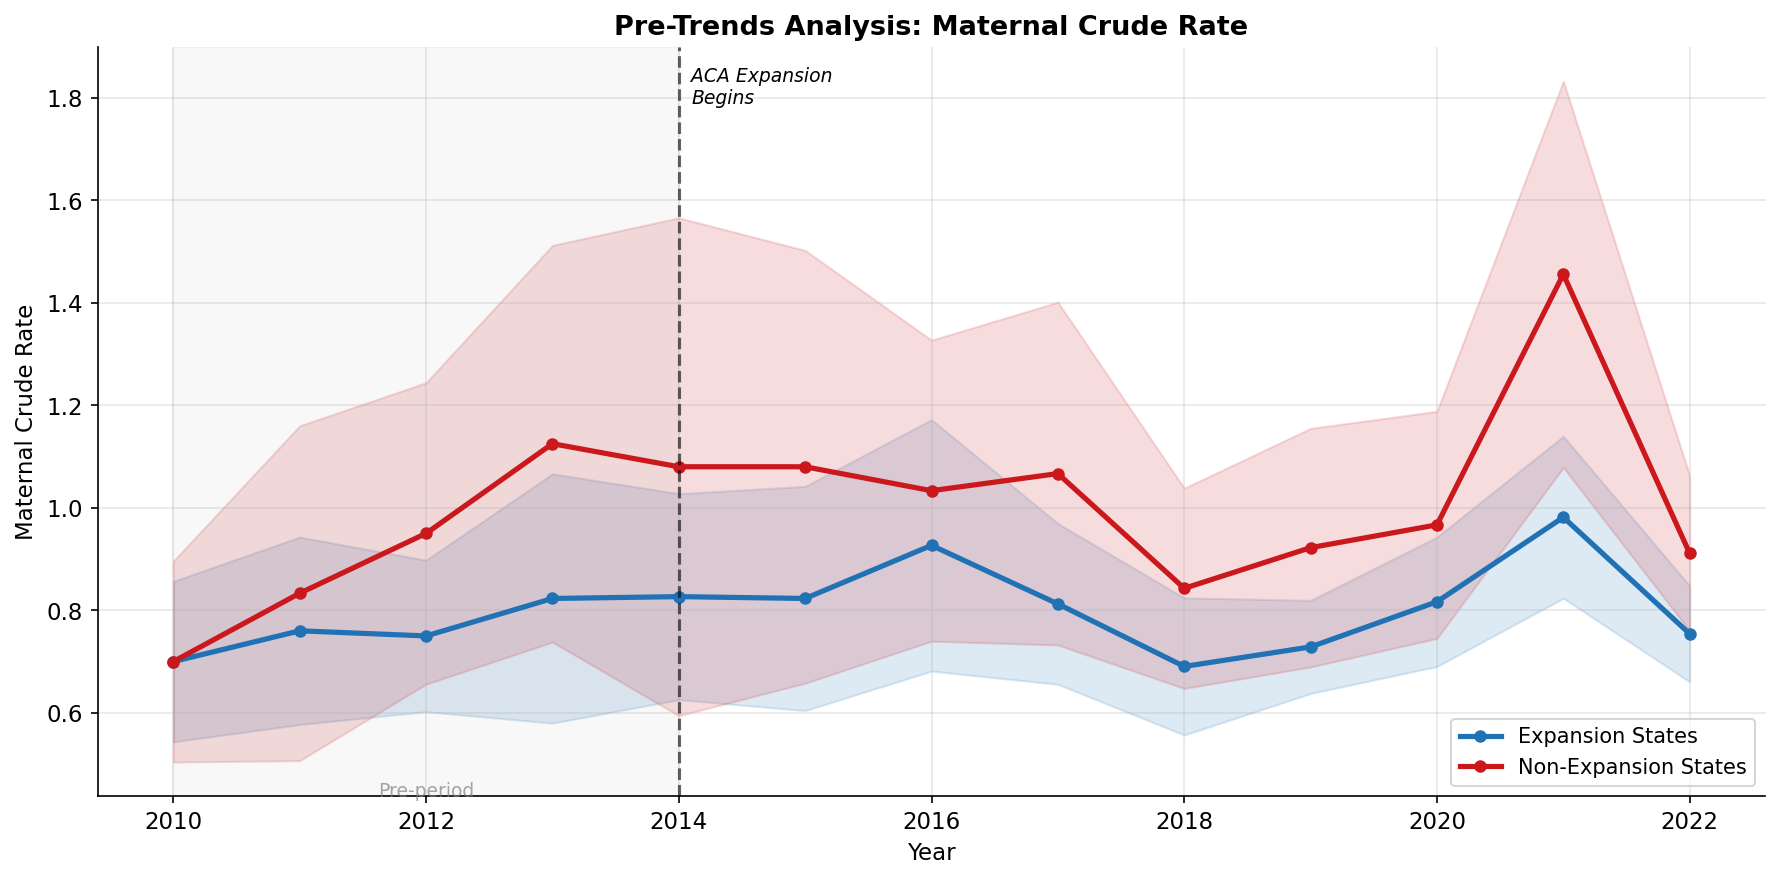

Saved: figures/pre_trends_maternal_crude_rate.png



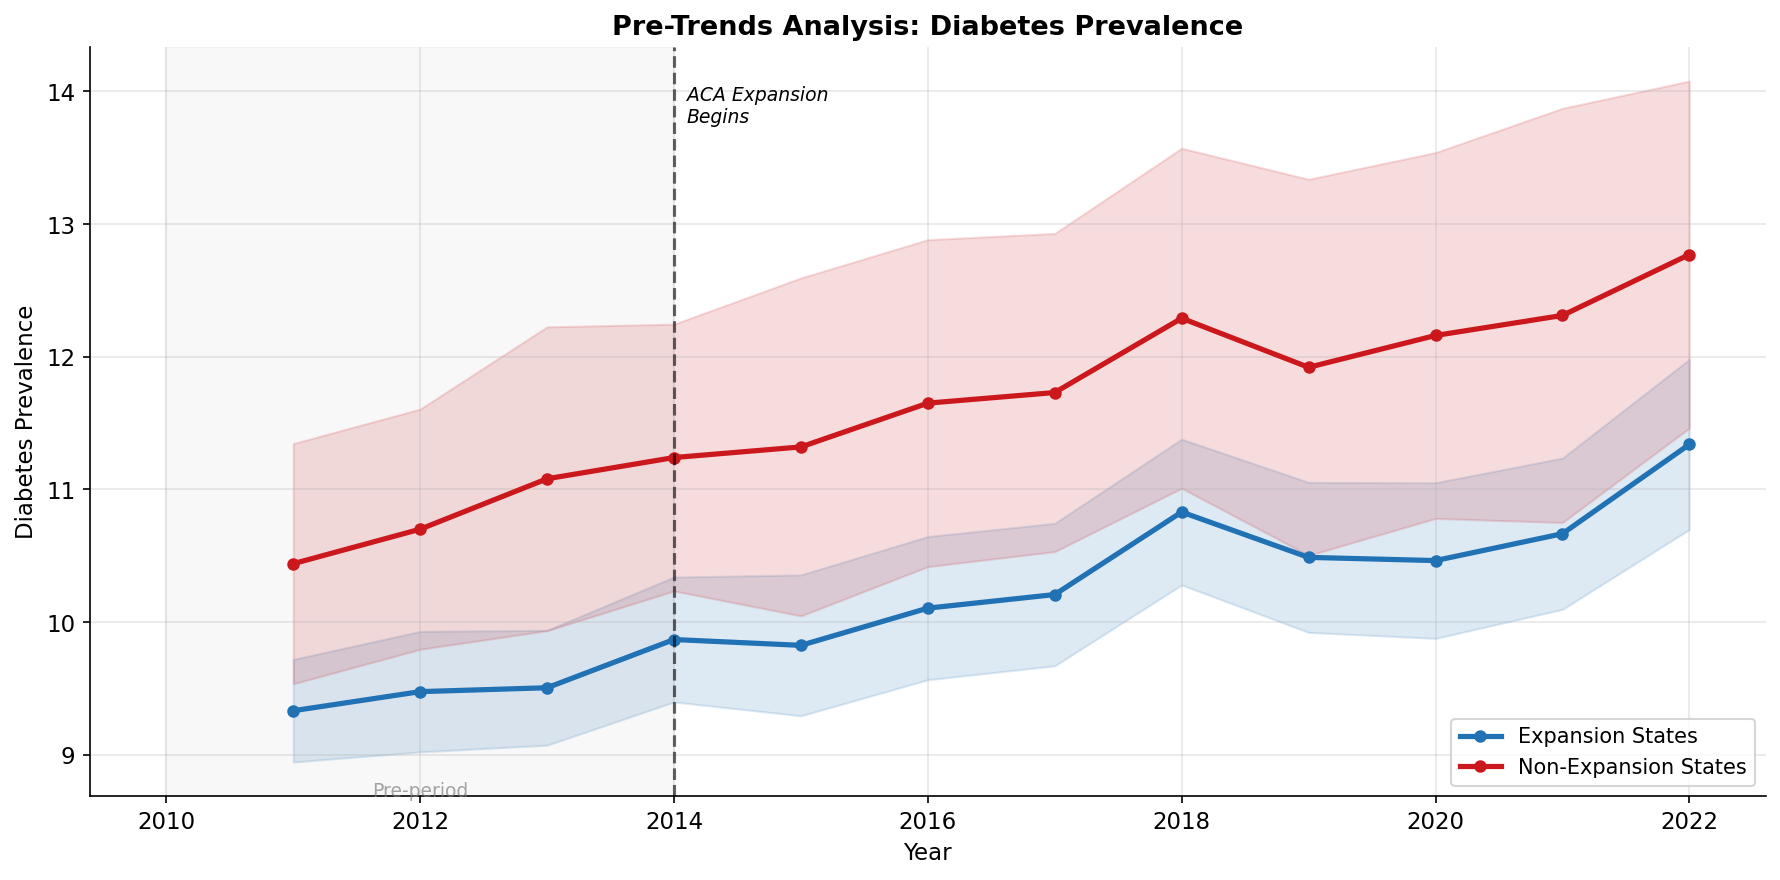

Saved: figures/pre_trends_diabetes_prevalence.png



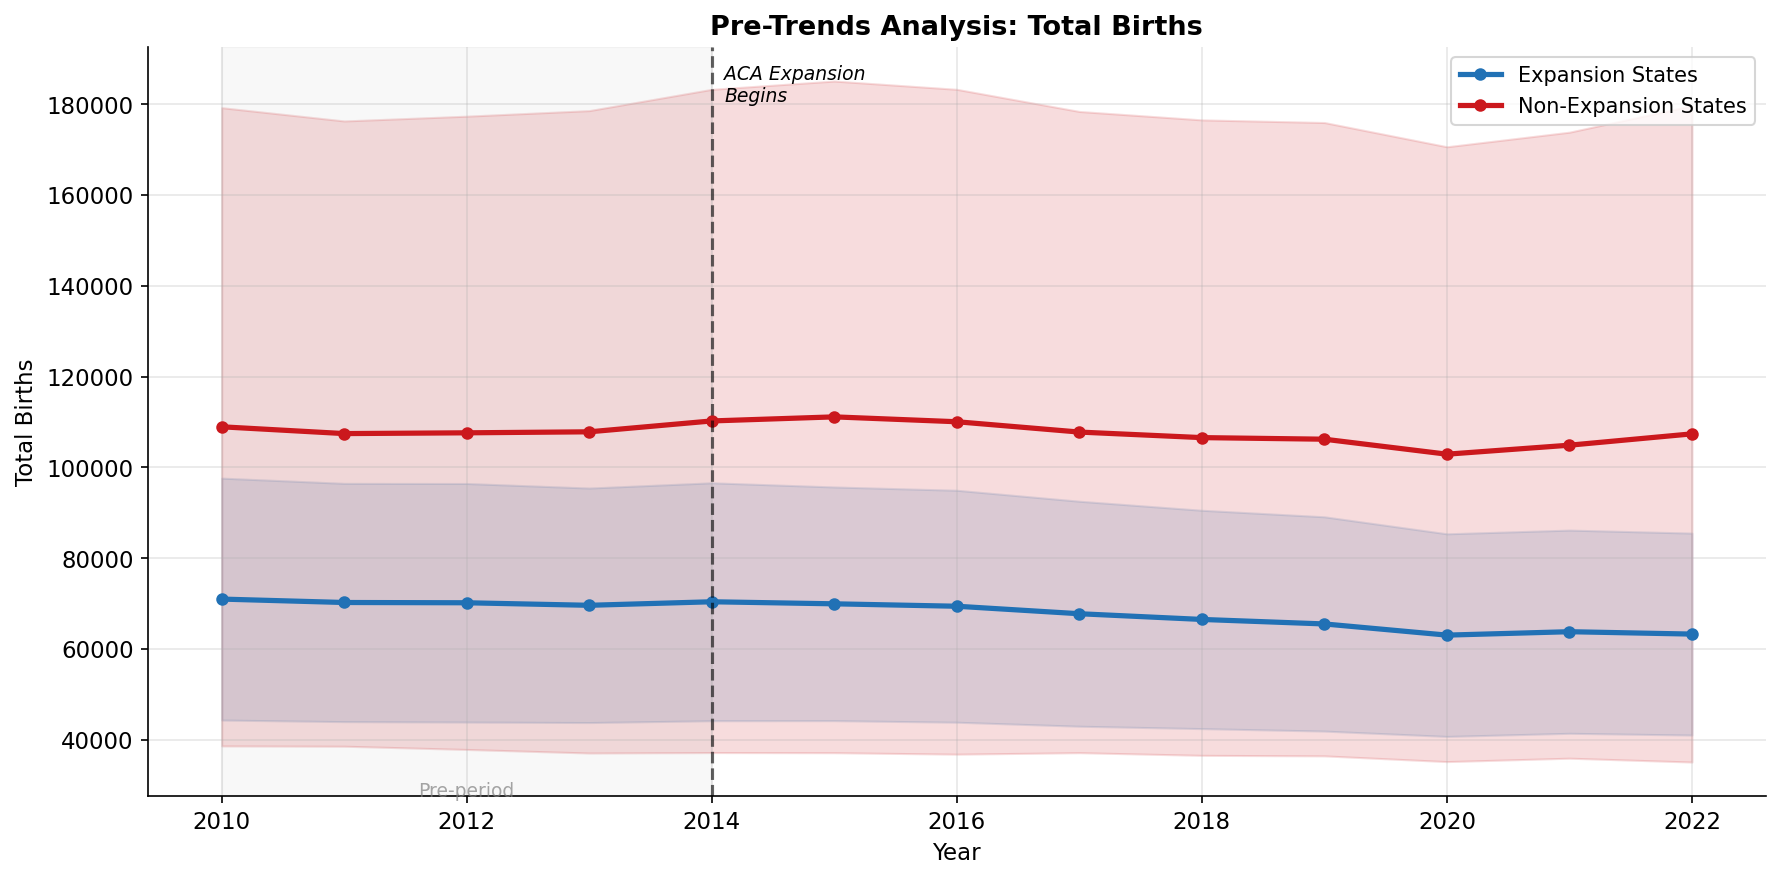

Saved: figures/pre_trends_total_births.png



In [9]:
# Plot pre-trends for all available outcomes
for var in outcome_vars:
    fig = plot_pre_trends(panel, var)
    if fig:
        safe_name = var.replace(' ', '_').lower()
        fig.savefig(f'../figures/pre_trends_{safe_name}.png', dpi=150, bbox_inches='tight')
        plt.show()
        print(f"Saved: figures/pre_trends_{safe_name}.png\n")

---
## 5. Outcome Distributions

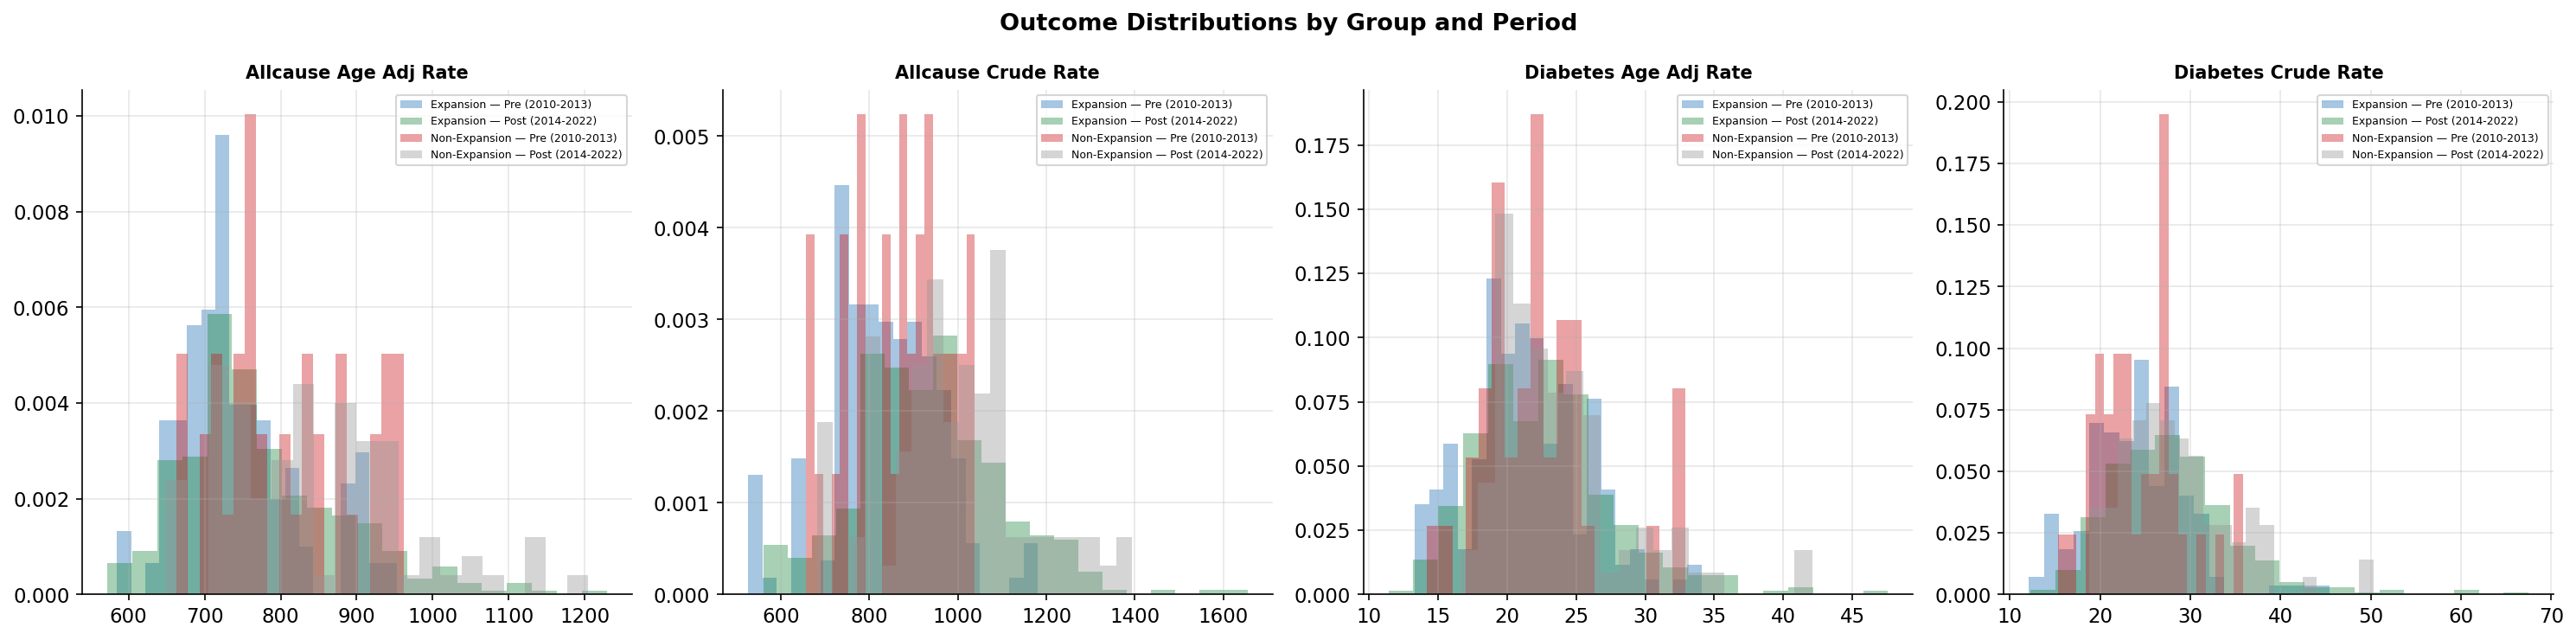

In [10]:
# Distribution of outcomes by expansion status (pre vs post)
if outcome_vars:
    panel['period'] = np.where(panel['year'] < 2014, 'Pre (2010-2013)', 'Post (2014-2022)')
    panel['group'] = np.where(panel['ever_expanded'] == 1, 'Expansion', 'Non-Expansion')
    panel['group_period'] = panel['group'] + ' — ' + panel['period']
    
    n_vars = min(len(outcome_vars), 4)  # Plot up to 4
    fig, axes = plt.subplots(1, n_vars, figsize=(5 * n_vars, 5))
    if n_vars == 1:
        axes = [axes]
    
    for i, var in enumerate(outcome_vars[:n_vars]):
        ax = axes[i]
        for gp, color in [
            ('Expansion — Pre (2010-2013)', COLORS['expansion']),
            ('Expansion — Post (2014-2022)', COLORS['highlight']),
            ('Non-Expansion — Pre (2010-2013)', COLORS['no_expansion']),
            ('Non-Expansion — Post (2014-2022)', COLORS['neutral']),
        ]:
            data = panel[panel['group_period'] == gp][var].dropna()
            if len(data) > 0:
                ax.hist(data, bins=20, alpha=0.4, color=color, label=gp, density=True)
        
        ax.set_title(var.replace('_', ' ').title()[:30], fontsize=10, fontweight='bold')
        ax.legend(fontsize=6)
    
    plt.suptitle('Outcome Distributions by Group and Period', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../figures/outcome_distributions.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Clean up temp columns
    panel = panel.drop(columns=['period', 'group', 'group_period'])
else:
    print("No outcome data available for distribution plots.")

---
## 6. Correlation Matrix

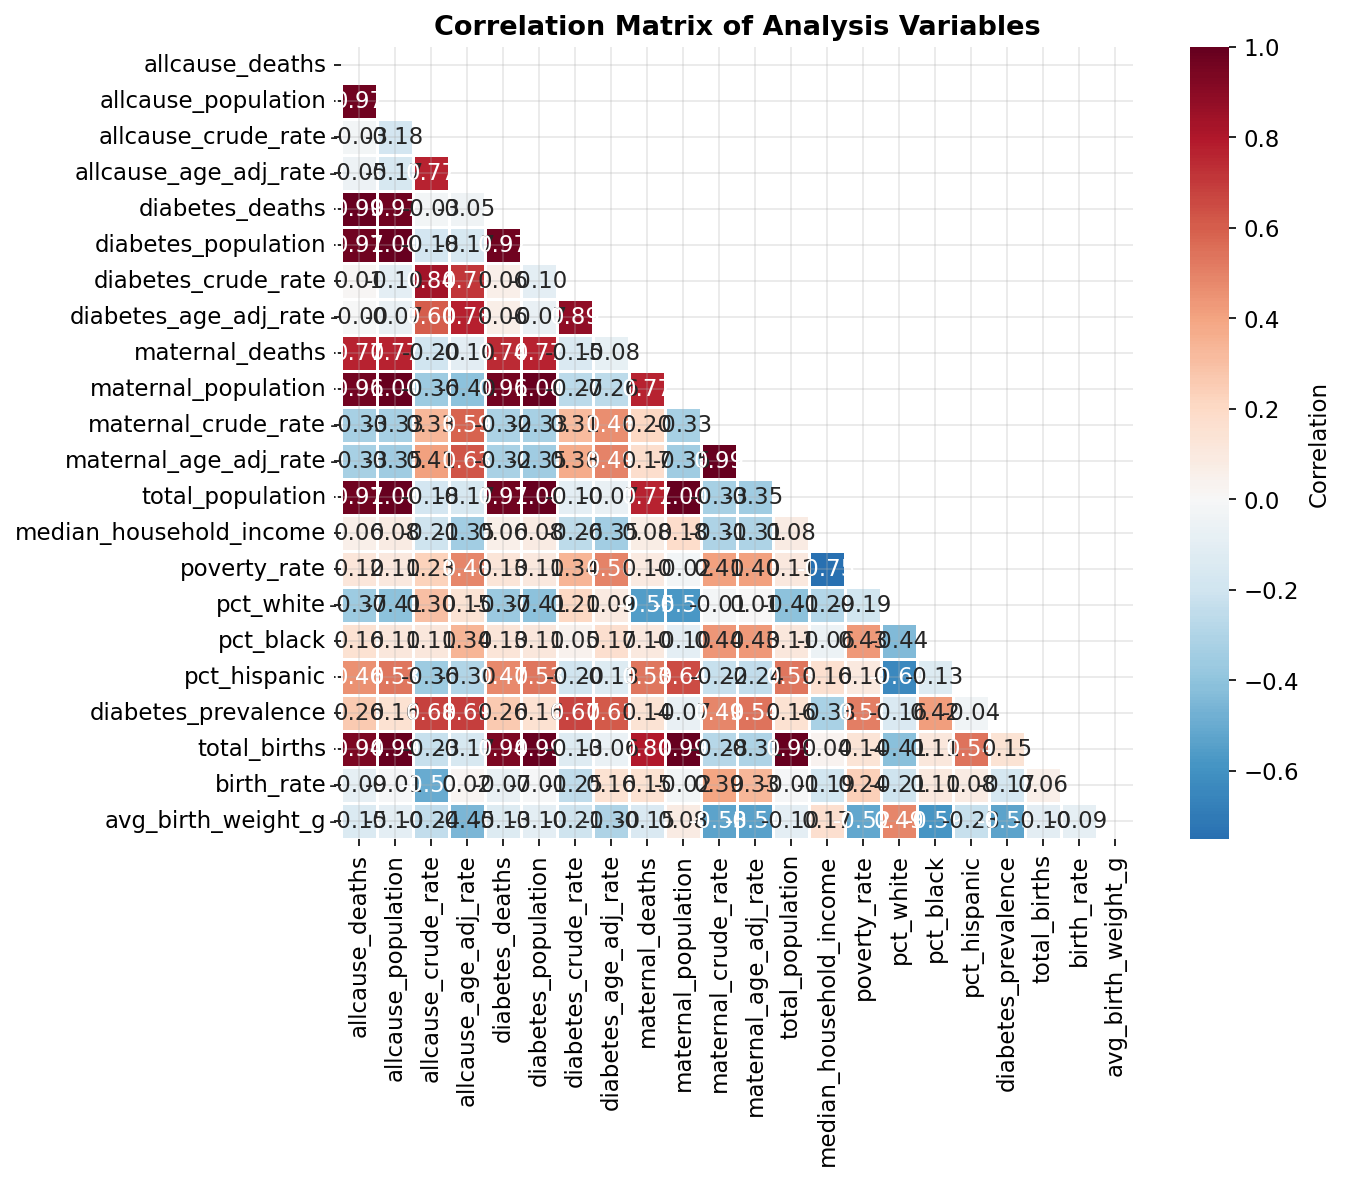

Saved: figures/correlation_matrix.png


In [11]:
# Correlation heatmap of all numeric variables
all_analysis_vars = [c for c in numeric_cols if panel[c].notna().sum() > 100]

if len(all_analysis_vars) >= 3:
    corr = panel[all_analysis_vars].corr()
    
    fig, ax = plt.subplots(figsize=(10, 8))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, ax=ax, square=True, linewidths=0.5,
                cbar_kws={'label': 'Correlation'})
    ax.set_title('Correlation Matrix of Analysis Variables', fontsize=13, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('../figures/correlation_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: figures/correlation_matrix.png")
else:
    print(f"Only {len(all_analysis_vars)} variables available — need at least 3 for correlation matrix.")

---
## 7. Treatment Variation Summary

Important for understanding the staggered design — how much variation in treatment timing do we have?

In [12]:
# Treatment timing distribution
state_info = panel.groupby('state').agg(
    expansion_year=('expansion_year', 'first'),
    ever_expanded=('ever_expanded', 'first'),
    cohort=('cohort', 'first')
).reset_index()

print("Expansion Cohort Summary:")
print("=" * 50)
cohort_counts = state_info.groupby('cohort').size().reset_index(name='n_states')
print(cohort_counts.to_string(index=False))

print(f"\nTotal expanded: {state_info['ever_expanded'].sum()}")
print(f"Total never expanded: {(state_info['ever_expanded'] == 0).sum()}")
print(f"Unique expansion years: {sorted(state_info[state_info['ever_expanded']==1]['expansion_year'].unique())}")

Expansion Cohort Summary:
      cohort  n_states
Early (2014)        27
 Late (2015)         3
 Late (2016)         2
 Late (2019)         2
 Late (2020)         3
 Late (2021)         2
 Late (2023)         2
       Never        10

Total expanded: 41
Total never expanded: 10
Unique expansion years: [np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2023)]


In [13]:
# List states by expansion status
print("\nNon-Expansion States (Control Group):")
print(", ".join(sorted(state_info[state_info['ever_expanded'] == 0]['state'].tolist())))

print("\nLate Expansion States (2015+):")
late = state_info[(state_info['ever_expanded'] == 1) & (state_info['expansion_year'] > 2014)]
for _, row in late.sort_values('expansion_year').iterrows():
    print(f"  {row['state']}: {int(row['expansion_year'])}")


Non-Expansion States (Control Group):
Alabama, Florida, Georgia, Kansas, Mississippi, South Carolina, Tennessee, Texas, Wisconsin, Wyoming

Late Expansion States (2015+):
  Alaska: 2015
  Indiana: 2015
  Pennsylvania: 2015
  Louisiana: 2016
  Montana: 2016
  Maine: 2019
  Virginia: 2019
  Idaho: 2020
  Utah: 2020
  Nebraska: 2020
  Missouri: 2021
  Oklahoma: 2021
  South Dakota: 2023
  North Carolina: 2023


---
## Summary & Next Steps

### Key EDA Findings

*(Update these as you add outcome data)*

1. **Staggered adoption:** Expansion was adopted across multiple years (2014–2023), providing treatment timing variation necessary for modern DiD estimators.
2. **Control group:** 10 states never expanded, serving as the primary control group.
3. **Pre-trends:** *(Assess visually from plots above — do expansion and non-expansion states track together before 2014?)*
4. **Covariate balance:** *(Note any large pre-treatment differences in demographics/economics)*

### Figures Generated
All saved to `figures/` directory for use in README and presentations.

### Proceed to:
- **`04_did_analysis.ipynb`** — Difference-in-differences estimation
- **`R/01_did_callaway_santanna.R`** — Modern DiD estimators in R